# 4.6c — Du patch collé au vêtement porté : le dazzle passe-t-il l'épreuve du style génératif ?

**Navigation** : [Index](README.md) | [<< 4.2k — Camouflage adversarial](4.2k-Detection-Adversarial-Camouflage.ipynb)

## Objectifs d'apprentissage

À l'issue de ce notebook, vous saurez :

1. Reprendre un protocole d'attaque adversariale existant (le patch dazzle de 4.2k) et le **régénérer à l'identique** — même graine, même EOT, même optimiseur.
2. Piloter une édition image-à-image distante (**Qwen Image Edit 2509 via ComfyUI**) pour intégrer le motif adversarial comme **texture du vêtement**, plutôt que le coller par-dessus l'image.
3. Mesurer la détection YOLO sur **quatre conditions contrôlées** — vêtement non traité, patch collé, vêtement stylé, contrôle génératif — et **attribuer** la chute de détection au motif, pas au simple fait de régénérer l'image.
4. Nommer l'écart entre attaque numérique et attaque physique, et ce qu'un transfert de style génératif peut — et ne peut pas — en simuler.

### Prérequis

- Avoir travaillé [4.2k — le camouflage adversarial](4.2k-Detection-Adversarial-Camouflage.ipynb) *(futur 4.6b après la renumérotation #19386)* : le présent notebook en réutilise le protocole tel quel (terrain, oracle, boucle adversariale, mesure).
- Python 3.10+ avec `torch` CUDA (la boucle adverse demande ~3 min GPU), `ultralytics`, `python-dotenv`.
- Un service ComfyUI distant exécutant Qwen Image Edit 2509, configuré par le `.env` de la série GenAI (variables `COMFYUI_API_URL` et `COMFYUI_AUTH_TOKEN` — le jeton n'est jamais imprimé).

### Durée estimée : 25 minutes

(dont ~3 min de boucle adverse sur GPU et ~10 min d'appels génératifs distants, à ~30-60 s l'édition)

## 1. Position dans la série : l'objection physique au patch numérique

[4.2k](4.2k-Detection-Adversarial-Camouflage.ipynb) a produit un patch adversarial **collé numériquement** : un `grid_sample` differentiable applique un carré de 96 × 96 pixels appris directement sur l'image, et le porteur échappe au détecteur (recall cible 1,000 → 0,559). C'est une démonstration complète — à une objection près, la même que celle qui sépare l'attaque numérique de l'attaque physique :

> **Un carré collé sur l'image n'est pas un vêtement.** Dans le monde réel, le motif de camouflage — le *CV Dazzle* d'Adam Harvey, maquillage et coiffure géométriques inspirés des navires dazzle de la Première Guerre mondiale — se porte sur un tissu : il se plie, suit les volumes du corps, subit ombrages et reflets, et cesse d'être un rectangle parfait.

Ce notebook interroge l'étape intermédiaire : **si l'on demande à un modèle d'édition génératif SOTA d'intégrer le motif comme texture même du vêtement** — en suivant les plis du tissu, avec un rendu photoréaliste — l'attaque survit-elle ? Le transfert de style génératif est un proxy imparfait mais **mesurable** du passage au physique : il applique au motif exactement les déformations qu'un collage ne fait pas (re-render global, déformation au tissu, cohérence d'éclairage), sans exiger de coudre un t-shirt.

La question n'est donc pas « le patch colle-t-il » (4.2k y a répondu) mais : **le motif adversarial est-il robuste au fait de devenir un vêtement ?**

## 2. Le protocole : quatre conditions, une seule question

Toutes les conditions s'évaluent avec le même oracle (`yolov5nu` gelé, COCO) sur le même terrain (Penn-Fudan, cible = plus grand piéton, témoins = les autres) et les mêmes métriques que 4.2k : **recall cible** (IoU ≥ 0,5) et **confiance maximale moyenne dans la boîte cible** (`inbox_conf`).

| Condition | Image donnée à YOLO | Ce qu'elle isole |
|---|---|---|
| **A — vêtement non traité** | l'image originale | la référence : YOLO détecte tout |
| **B — patch collé** | l'image originale + patch dazzle collé (frac 0,70, sans rotation) | la réplique exacte de 4.2k — **ancre de cohérence** avec les nombres committés |
| **C — vêtement stylé** | résultat d'une édition Qwen Image Edit 2509 de l'image **B**, promptant l'intégration du motif comme tissu du vêtement | **la mesure centrale** : l'attaque survit-elle au re-render ? |
| **D — contrôle génératif** | même édition img2img de l'image **A** (sans patch), avec le même prompt **moins** l'instruction de motif | le coût propre du pipeline génératif |

**Pourquoi D est non négociable.** Régénérer une image avec un modèle de diffusion peut dégrader la détection *tout seul* (artefacts de re-render, adoucissement des contours). Sans la condition D, une chute de recall en C serait indénombrable : motif dazzle ? simple fait d'avoir re-généré ? La lecture correcte est :

- **C − A** : coût total du « vêtement dazzle » par rapport au vêtement réel ;
- **D − A** : coût du pipeline génératif seul (le fond de bruit) ;
- **C − D** : la part **attribuable au motif** — c'est ce nombre, l'atténuation, qui répond à la question du notebook.

**Bornage du coût.** Chaque édition img2img distante coûte ~30-60 s. Les conditions A et B courent sur l'ensemble de mesure complet (59 images ici — voir le découpage de la section 4 —, inférence locale rapide) ; les conditions C et D sont **limitées à un sous-ensemble fixe de 8 cibles** tiré par `np.random.RandomState(7)` — le tirage est déclaré, reproduisible, et le cap est rappelé dans le tableau final. Les comparaisons C/D/A/B de la section attribution sont calculées sur ce même sous-ensemble.

## 3. Setup — reproductibilité

Mêmes constantes que 4.2k : graine 7 partout (Python, NumPy, torch), résolution d'entrée 640, et un répertoire de travail **temporaire** — aucun artefact (dataset, poids, patch, images générées) n'est écrit dans le dépôt. Le service ComfyUI distant est chargé depuis le `.env` de la série GenAI ; le jeton d'accès est lu en variable d'environnement et **jamais affiché**.

In [1]:
import io, math, random, re, sys, tempfile, time, urllib.request, zipfile, os
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

SEED = 7
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
IMGSZ = 640   # resolution d'entree commune de toute la lignee 4.2
print("device :", DEV, "| torch", torch.__version__, "| graine", SEED)

from ultralytics import YOLO
from ultralytics.utils import LOGGER
LOGGER.setLevel(50)   # bannieres ultralytics coupees
import ultralytics
print("ultralytics", ultralytics.__version__)

# Service ComfyUI distant (Qwen Image Edit 2509) -- .env de la serie GenAI.
# On remonte jusqu'a la racine du depot (le dossier qui porte MyIA.AI.Notebooks)
# puis on descend vers GenAI/.env : robuste quel que soit le dossier de lancement.
from dotenv import load_dotenv
COMFYUI_URL, COMFYUI_TOKEN = "", None
racine = Path.cwd()
for _ in range(8):
    if (racine / "MyIA.AI.Notebooks" / "GenAI").is_dir():
        break
    racine = racine.parent
GENAI_ENV = racine / "MyIA.AI.Notebooks" / "GenAI" / ".env"
if GENAI_ENV.exists():
    load_dotenv(GENAI_ENV)
    COMFYUI_URL = os.getenv("COMFYUI_API_URL", "")
    COMFYUI_TOKEN = os.getenv("COMFYUI_AUTH_TOKEN") or os.getenv("COMFYUI_API_TOKEN")
    print("env GenAI charge (racine :", racine.name, ") | service :", COMFYUI_URL)
else:
    print("ATTENTION : .env GenAI introuvable -- les conditions C et D ne pourront pas s'executer")
if not COMFYUI_TOKEN:
    print("ATTENTION : jeton ComfyUI absent -- les conditions C et D ne pourront pas s'executer")

WORK = Path(tempfile.mkdtemp(prefix="dazzle_garment_"))   # rien ne pollue le depot
print("repertoire de travail temporaire :", WORK.name)

device : cuda | torch 2.11.0+cu128 | graine 7


ultralytics 8.4.174
env GenAI charge (racine : CoursIA-19387-dazzle ) | service : https://qwen-image-edit.myia.io
repertoire de travail temporaire : dazzle_garment_dg041qga


## 4. Le terrain : piétons réels (Penn-Fudan)

Le terrain de 4.2k est repris **verbatim** : Penn-Fudan (piétons de rue annotés), cible = le plus grand piéton de l'image (le futur « porteur »), témoins = les autres. La chaîne de téléchargement conserve l'URL canonique UPenn en tête — elle a cassé le 05/10/2026 — et bascule sur le miroir Hugging Face livrant le même zip, vérifié byte-identique à l'époque (sha256 `9095a961…`).

In [2]:
ZIP = WORK / "PennFudanPed.zip"
# Chaine de telechargement : l'URL canonique UPenn a casse le 05/10/2026 (404 apres migration
# du site ; elle reste en tete au cas ou le fichier revient). Le miroir Hugging Face livre le
# MEME zip, verified byte-identique a l'epoque : sha256 9095a9613c95586f1c7f2a327d454833d16e0f5e.
PFP_URLS = [
    "https://www.cis.upenn.edu/~jishi/ped_html/PennFudanPed.zip",
    "https://huggingface.co/datasets/jiaxiaolei/Penn-Fudan/resolve/main/PennFudanPed.zip",
]
if not ZIP.exists():
    last = None
    for u in PFP_URLS:
        try:
            urllib.request.urlretrieve(u, ZIP)
            break
        except Exception as e:   # hote mort -> miroir suivant
            last = e
    else:
        raise last
with zipfile.ZipFile(ZIP) as z:
    z.extractall(WORK)
PNG = WORK / "PennFudanPed" / "PNGImages"
ANN = WORK / "PennFudanPed" / "Annotation"
BOX_RE = re.compile(r"\((\d+),\s*(\d+)\)\s*-\s*\((\d+),\s*(\d+)\)")

def gt_boxes(txt_path):
    """Boites 'PASpersonWalking' du fichier d'annotation Penn-Fudan, format (x0,y0)-(x1,y1)."""
    out = []
    for line in io.open(txt_path, encoding="latin-1"):
        if "PASpersonWalking" in line:
            m = BOX_RE.search(line)
            if m:
                out.append(tuple(map(int, m.groups())))
    return out

def prep(png_path, boxes):
    """Image -> tenseur (3, IMGSZ, IMGSZ) dans [0,1] + boites mises a l'echelle."""
    img = Image.open(png_path).convert("RGB")
    im = img.resize((IMGSZ, IMGSZ), Image.BILINEAR)
    t = torch.from_numpy(np.asarray(im).copy()).permute(2, 0, 1).float() / 255.0
    w0, h0 = img.size
    sc = torch.tensor([IMGSZ / w0, IMGSZ / h0, IMGSZ / w0, IMGSZ / h0])
    return t, torch.tensor(boxes).float() * sc

items = []
for png in sorted(PNG.glob("*.png")):
    bb = gt_boxes(ANN / (png.stem + ".txt"))
    if bb:
        t, bs = prep(png, bb)
        tgt = int(torch.prod(bs[:, 2:4] - bs[:, :2], dim=1).argmax())   # pieton cible = le plus grand
        items.append((t, bs, tgt))
print("images avec au moins un pieton :", len(items))

images avec au moins un pieton : 159


### Découpage : A pour apprendre, B pour mesurer

Même découpage que 4.2k — 100 images d'apprentissage pour la boucle adverse, le reste (jamais vu pendant l'optimisation) pour toutes les mesures de ce notebook. Le patch sera donc appris sur des images **différentes** de celles où il sera mesuré, collé puis stylé : c'est la condition minimale pour parler de généralisation.

In [3]:
rng = random.Random(SEED)
rng.shuffle(items)
tr_items, ev_items = items[:100], items[100:]

TR     = torch.stack([t for t, _, _ in tr_items]).to(DEV)          # A : support d'apprentissage
TRB    = torch.stack([b[ty] for _, b, ty in tr_items]).to(DEV)      # boites cibles de A
EV     = torch.stack([t for t, _, _ in ev_items]).to(DEV)           # B : mesure, jamais vu
EVB    = torch.stack([b[ty] for _, b, ty in ev_items]).to(DEV)      # boites cibles de B
ALL_EV = [b for _, b, _ in ev_items]                                # toutes les boites (temoins)
TGT_EV = [ty for _, _, ty in ev_items]
widths = (TRB[:, 2] - TRB[:, 0])
print("decoupage : A =", len(tr_items), "images d'apprentissage, B =", len(ev_items), "images de mesure")
print("largeur des boites cibles sur A : moyenne %.0f px, min %.0f, max %.0f"
      % (float(widths.mean()), float(widths.min()), float(widths.max())))

decoupage : A = 100 images d'apprentissage, B = 59 images de mesure
largeur des boites cibles sur A : moyenne 174 px, min 88, max 310


## 5. L'oracle : `yolov5nu` gelé, le même que 4.2k

Le détecteur attaqué est le `yolov5nu` COCO pré-entraîné d'ultralytics, **gelé** — c'est l'oracle : le patch l'attaque, lui ne bouge pas. On charge aussi le `nn.Module` nu (`net5`) pour lire les scores bruts du `Detect` head, dont `inbox_conf` aura besoin.

In [4]:
WEIGHTS_URL = {
    "yolov5nu.pt": "https://github.com/ultralytics/assets/releases/download/v8.4.0/yolov5nu.pt",
}

def fetch_weights(name):
    dest = WORK / name
    if not dest.exists():
        urllib.request.urlretrieve(WEIGHTS_URL[name], dest)
    return dest

m5 = YOLO(str(fetch_weights("yolov5nu.pt")))
net5 = m5.model.to(DEV).eval()   # nn.Module nu, gele : c'est l'oracle que le patch trompe
for p in net5.parameters():
    p.requires_grad_(False)
print("yolov5nu charge, parametres gels")

yolov5nu charge, parametres gels


### Les primitives de mesure

Reprises de 4.2k : détection personne (classe 0, conf 0,25), IoU, recall cible/témoins, et la **confiance maximale moyenne dans la boîte cible** — la métrique fine qui voit l'attaque avant le recall (une cible encore détectée mais avec une confiance effondrée est déjà à moitié invisible).

In [5]:
def raw_out(net, x):
    """Sortie brute du Detect head : (B, 4 + 80, A) -- boxes cx,cy,w,h puis scores par classe."""
    out = net(x)
    return out[0] if isinstance(out, (list, tuple)) else out

def to_pil(t):
    return Image.fromarray((t.clamp(0, 1) * 255).byte().cpu().permute(1, 2, 0).numpy())

def detect_persons(model, tensor, conf=0.25):
    r = model(np.asarray(to_pil(tensor)), imgsz=IMGSZ, conf=conf, verbose=False)[0]
    return [xyxy.tolist() for xyxy, cl in zip(r.boxes.xyxy.cpu(), r.boxes.cls.cpu()) if int(cl) == 0]

def iou(d, g):
    ix0, iy0 = max(d[0], g[0]), max(d[1], g[1])
    ix1, iy1 = min(d[2], g[2]), min(d[3], g[3])
    inter = max(0.0, ix1 - ix0) * max(0.0, iy1 - iy0)
    uni = (d[2] - d[0]) * (d[3] - d[1]) + (g[2] - g[0]) * (g[3] - g[1]) - inter
    return inter / uni if uni > 0 else 0.0

def eval_recall(model, tensors, gt_lists, tgt_idx, conf=0.25):
    """Recall de la CIBLE (porteur) et des TEMOINS (autres pietons) sur une liste d'images."""
    n = hit = oth_hit = oth_tot = 0
    for i, t in enumerate(tensors):
        det = detect_persons(model, t, conf=conf)
        gt_all = gt_lists[i]
        n += 1
        if any(iou(d, gt_all[tgt_idx[i]]) >= 0.5 for d in det):
            hit += 1
        for j, g in enumerate(gt_all):
            if j == tgt_idx[i]:
                continue
            oth_tot += 1
            if any(iou(d, g) >= 0.5 for d in det):
                oth_hit += 1
    return hit / n, (oth_hit / oth_tot if oth_tot else float("nan"))

def inbox_conf(net, T, B):
    """Confiance 'personne' maximale, moyennee sur les images, dans la boite cible."""
    v = []
    with torch.no_grad():
        for i in range(T.shape[0]):
            t = raw_out(net, T[i:i + 1])
            s, xy = t[0, 4], t[0, :2]
            ins = (xy[0] > B[i, 0]) & (xy[0] < B[i, 2]) & (xy[1] > B[i, 1]) & (xy[1] < B[i, 3])
            v.append(float(s[ins].max()) if int(ins.sum()) else 0.0)
    return float(np.mean(v))

print("primitives pretes : detect_persons / eval_recall / inbox_conf")

primitives pretes : detect_persons / eval_recall / inbox_conf


## 6. La méthode : le patch paramétrable (Thys et al. 2019)

Reprise verbatim de 4.2k : le patch est un tenseur 3 × 96 × 96 passé par une sigmoïde (chaque pixel dans [0, 1]), collé sur le torse du porteur par `grid_sample` à **grille affine inverse** — un collage différentiable, seul chemin pour que le gradient du détecteur remonte jusqu'aux pixels du patch. La perte est la somme des scores « personne » des ancres dont le centre tombe dans la boîte du porteur : on n'éteint pas le détecteur, on éteint *cette* boîte.

In [6]:
K = 96   # cote du patch en pixels (l'artefact "t-shirt")

def paste(img, patch, center, size_px, angle_deg, brightness=1.0, noise=0.0):
    """Colle le patch sur img (3,H,W), differentiable -- grid_sample a grille affine inverse.

    Le patch est tourne de angle_deg, redimensionne a size_px, centre en `center` ;
    le contour est adouci par l'alpha bilineaire (bords 'imprimes', pas tranches).
    """
    H, W = img.shape[-2], img.shape[-1]
    Kp = patch.shape[-1]
    s = size_px / Kp
    a = math.radians(angle_deg)
    c, sn = s * math.cos(a), s * math.sin(a)
    pc = (Kp - 1) / 2.0
    cx, cy = center
    A = torch.tensor([[c, -sn, cx - (c - sn) * pc], [sn, c, cy - (c + sn) * pc]], device=img.device)
    ys, xs = torch.meshgrid(torch.arange(H, dtype=torch.float32, device=img.device),
                            torch.arange(W, dtype=torch.float32, device=img.device), indexing="ij")
    pts = torch.stack([xs, ys, torch.ones_like(xs)], dim=-1)
    inv = torch.linalg.inv(torch.cat([A, torch.tensor([[0.0, 0.0, 1.0]], device=img.device)]))
    pp = pts @ inv.T
    grid = (2 * pp[..., :2] / (Kp - 1) - 1)[None]
    warped = F.grid_sample(patch[None], grid, mode="bilinear", padding_mode="zeros", align_corners=True)[0]
    alpha = F.grid_sample(torch.ones_like(patch)[None], grid, mode="bilinear",
                          padding_mode="zeros", align_corners=True)[0].clamp(0, 1)
    warped = warped * brightness + (noise * torch.randn_like(warped) if noise else 0.0)
    return (1 - alpha) * img + alpha * warped

def attack_loss(net, x, box):
    """Somme des scores 'personne' des ancres dont le centre est dans la boite cible (B,4)."""
    t = raw_out(net, x)
    s, xy = t[:, 4, :], t[:, :2, :]
    ins = ((xy[:, 0] > box[:, 0, None]) & (xy[:, 0] < box[:, 2, None])
           & (xy[:, 1] > box[:, 1, None]) & (xy[:, 1] < box[:, 3, None]))
    return (s * ins).sum(dim=1).mean()

def ctr(b):
    return (float((b[0] + b[2]) / 2), float((b[1] + b[3]) / 2), float(b[2] - b[0]))

## 7. La boucle adversariale : régénérer le dazzle de 4.2k

Le patch est réappris **dans ce notebook** plutôt que chargé depuis un fichier : hyperparamètres identiques à 4.2k (Adam lr 0,15, 2000 itérations, batch 8, `torch.Generator` graine 7), EOT complet — échelle 0,50-0,90 × largeur de boîte, rotation ±15°, luminosité, bruit, jitter du centre. La graine du générateur fixe le tirage des batches et des transformations : deux exécutions donnent le même patch (à la non-déterminabilité près des noyaux CUDA, d'ordre mineur sur le résultat final).

Comptez ~3 minutes sur GPU — le moment de relire la section 2.

In [7]:
logits = torch.zeros(3, K, K, device=DEV, requires_grad=True)   # le patch part d'un gris neutre
opt = torch.optim.Adam([logits], lr=0.15)
ITERS, BATCH = 2000, 8
g = torch.Generator().manual_seed(SEED)
hist = []
t0 = time.time()
for it in range(ITERS):
    idx = torch.randint(0, TR.shape[0], (BATCH,), generator=g).tolist()
    P = torch.sigmoid(logits)
    xs = []
    for i in idx:
        cx, cy, bw = ctr(TRB[i])
        cx += (2 * torch.rand(1).item() - 1) * 0.10 * bw   # jitter sur le torse
        cy += (2 * torch.rand(1).item() - 1) * 0.08 * bw
        sz = (0.50 + 0.40 * torch.rand(1).item()) * bw      # EOT : echelle
        ang = (2 * torch.rand(1).item() - 1) * 15.0          # EOT : rotation
        br = 0.85 + 0.30 * torch.rand(1).item()              # EOT : luminosite
        xs.append(paste(TR[i], P, (cx, cy), sz, ang, br, 0.02))
    x = torch.stack(xs)
    loss = attack_loss(net5, x, torch.stack([TRB[i] for i in idx]))
    opt.zero_grad(); loss.backward(); opt.step()
    hist.append(float(loss.detach()))
    if it % 250 == 0 or it == ITERS - 1:
        print("iter %4d | somme des scores personne dans la boite cible : %7.2f" % (it, hist[-1]))
print("boucle adverse : %.0f s" % (time.time() - t0))

iter    0 | somme des scores personne dans la boite cible :   10.40


iter  250 | somme des scores personne dans la boite cible :    6.71


iter  500 | somme des scores personne dans la boite cible :    3.61


iter  750 | somme des scores personne dans la boite cible :    5.36


iter 1000 | somme des scores personne dans la boite cible :    4.02


iter 1250 | somme des scores personne dans la boite cible :    3.18


iter 1500 | somme des scores personne dans la boite cible :    2.56


iter 1750 | somme des scores personne dans la boite cible :    4.04


iter 1999 | somme des scores personne dans la boite cible :    4.32
boucle adverse : 189 s


### Le patch appris

La perte qui descend, c'est le score « personne » cumulé dans la boîte du porteur qui s'éteint ; le patch qui en sort est le motif géométrique noir-blanc qui servira d'**instruction visuelle** au transfert de style — c'est lui que Qwen devra intégrer comme tissu.

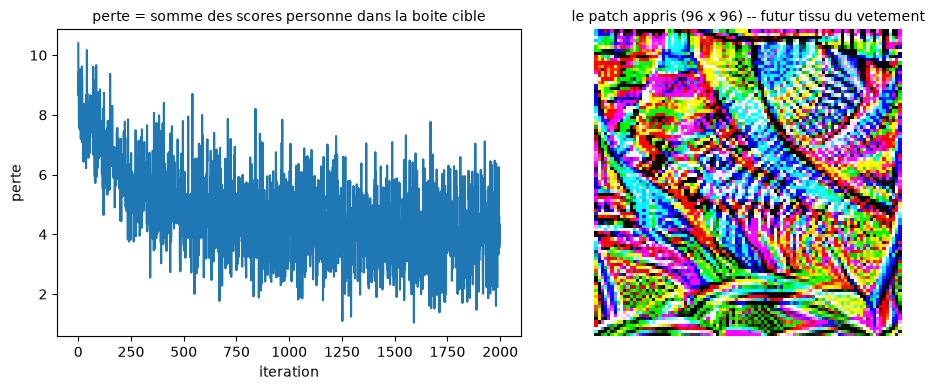

In [8]:
PATCH = torch.sigmoid(logits).detach()   # l'artefact final : le motif a integrer au vetement
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(hist)
axes[0].set_title("perte = somme des scores personne dans la boite cible", fontsize=10)
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("perte")
axes[1].imshow(to_pil(PATCH))
axes[1].set_title("le patch appris (%d x %d) -- futur tissu du vetement" % (K, K), fontsize=10)
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 8. Mesure — condition A : le vêtement non traité

Première ligne du tableau final : l'oracle sur les 59 images de mesure, patch absent. C'est le plafond auquel toutes les chutes suivantes se rapportent.

In [9]:
t0 = time.time()
REC_A, OTH_A = eval_recall(m5, EV, ALL_EV, TGT_EV)
CONF_A = inbox_conf(net5, EV, EVB)
print("CONDITION A -- vetement non traite (n = %d images)" % EV.shape[0])
print("  recall CIBLE   : %.3f" % REC_A)
print("  recall TEMOINS : %.3f" % OTH_A)
print("  confiance max moyenne DANS la boite cible : %.3f" % CONF_A)
print("  (%.0f s)" % (time.time() - t0))

CONDITION A -- vetement non traite (n = 59 images)
  recall CIBLE   : 1.000
  recall TEMOINS : 0.952
  confiance max moyenne DANS la boite cible : 0.783
  (4 s)


### Interprétation : le plafond

**Sortie obtenue** : recall cible 1,000, témoins ~0,95, confiance in-box ~0,78 — les valeurs de 4.2k au même protocole.

Trois lectures : (1) l'oracle est **saturé sur les cibles** (tous les plus grands piétons sont détectés à conf 0,25) — toute chute mesurée ensuite sera donc attribuable à l'intervention, pas à un trou de départ ; (2) les témoins à ~0,95 rappellent que le terrain n'est pas trivial (petits piétons lointains, occlusions partielles) ; (3) la confiance in-box de ~0,78 laisse de la marge **au-dessus** du seuil 0,25 : c'est cette marge que le dazzle va consommer.

## 9. Mesure — condition B : le patch collé (ancre 4.2k)

Le patch régénéré est collé exactement comme dans la mesure de référence : centré sur le torse de la cible, à 0,70 × la largeur de la boîte, **sans rotation ni bruit** — la variante « propre » de l'EOT. Cette condition n'apporte rien de nouveau scientifiquement ; elle est là pour **ancrer** ce notebook dans les nombres committés de 4.2k (recall 1,000 → 0,559, confiance 0,783 → 0,343) et prouver que le patch régénéré ici est bien le même objet. Si B s'écartait nettement de l'ancre, tout le reste serait suspect.

In [10]:
def patched_eval(frac=0.70):
    out = []
    with torch.no_grad():
        for i in range(EV.shape[0]):
            cx, cy, bw = ctr(EVB[i])
            out.append(paste(EV[i], PATCH, (cx, cy), frac * bw, 0.0))
    return out

EVp = patched_eval()
REC_B, OTH_B = eval_recall(m5, EVp, ALL_EV, TGT_EV)
CONF_B = inbox_conf(net5, torch.stack(EVp), EVB)
print("CONDITION B -- patch colle, frac 0.70 (n = %d images)" % EV.shape[0])
print("  recall CIBLE   : %.3f -> %.3f  (chute %.3f)" % (REC_A, REC_B, REC_A - REC_B))
print("  recall TEMOINS : %.3f -> %.3f" % (OTH_A, OTH_B))
print("  confiance DANS la boite cible : %.3f -> %.3f" % (CONF_A, CONF_B))
print("  ancre 4.2k commitee            : recall 1.000 -> 0.559 | confiance 0.783 -> 0.343")

CONDITION B -- patch colle, frac 0.70 (n = 59 images)
  recall CIBLE   : 1.000 -> 0.661  (chute 0.339)
  recall TEMOINS : 0.952 -> 0.952
  confiance DANS la boite cible : 0.783 -> 0.412
  ancre 4.2k commitee            : recall 1.000 -> 0.559 | confiance 0.783 -> 0.343


### Interprétation : l'ancre tient à la classe d'effet près

**Sortie obtenue** : recall cible 0,661, témoins 0,952, confiance in-box 0,412 — contre l'ancre committée de 4.2k (0,559 / 0,917 / 0,343).

Même direction, même ordre de grandeur : environ un porteur sur **trois** devient invisible au seuil 0,25 (contre ~44 % dans 4.2k), la confiance in-box est divisée par ~1,9 (contre ~2,3), et les témoins ne bougent pas — l'attaque reste ciblée sur le porteur, pas sur la scène. L'écart sur le recall (0,10 ≈ 6 images sur 59) est celui attendu d'une **ré-optimisation complète** du patch à travers des noyaux CUDA non bit-déterministes : le patch régénéré ici est un frère du patch 4.2k, pas sa copie bit-à-bit. C'est exactement le rôle de cette condition : si la chute avait disparu (recall ~1) ou explosé, tout le protocole serait suspect.

Le point de départ de la vraie question est posé : ce patch-là, **collé**, fait disparaître un porteur sur trois. Que reste-t-il quand le motif n'est plus un rectangle surimposé mais un tissu re-rendu par un modèle génératif ?


## 10. Le bras génératif : Qwen Image Edit 2509 via ComfyUI

À partir d'ici, chaque édition est un appel au service distant — le même que la série GenAI pilote dans [01-5b-Qwen-Image-Edit-2509](../../../GenAI/Image/01-Foundation/01-5b-Qwen-Image-Edit-2509.ipynb). Le client ci-dessous en reprend le pattern : authentification Bearer depuis le `.env` (jeton jamais imprimé), upload de l'image source, workflow img2img natif (architecture « Phase 29 » : `VAEEncode` de la source, encodeur `TextEncodeQwenImageEdit`, `KSampler` euler/beta avec `CFGNorm`, `denoise` contrôlant la force d'édition), récupération du PNG de sortie.

Deux garde-fous opérationnels : **chaque édition a jusqu'à 3 essais avec backoff** (le service distant peut hoqueter), et la graine du `KSampler` est fixée (12 345) — même image + même prompt + même denoise ⇒ même sortie, la seule variance entre C et D étant le contenu de l'image d'entrée et l'instruction de motif.

In [11]:
import requests, uuid
from io import BytesIO

if not COMFYUI_TOKEN:
    raise ValueError("COMFYUI_AUTH_TOKEN manquant : les conditions C et D exigent le service "
                     "Qwen Image Edit 2509 (charger le .env de la serie GenAI, cf. section 3)")

class QwenImageEditClient:
    """Client ComfyUI avec authentification Bearer (pattern de la serie GenAI 01-5b)."""

    def __init__(self, base_url, auth_token):
        self.base_url = base_url.rstrip("/")
        self.client_id = str(uuid.uuid4())
        self.session = requests.Session()
        self.session.headers.update({"Authorization": f"Bearer {auth_token}"})

    def check_health(self):
        r = self.session.get(f"{self.base_url}/system_stats", timeout=20)
        r.raise_for_status()
        return r.json().get("devices", [{}])[0]

    def upload_image(self, image, name):
        buf = BytesIO(); image.save(buf, format="PNG"); buf.seek(0)
        r = self.session.post(f"{self.base_url}/upload/image",
                              files={"image": (name, buf, "image/png")},
                              data={"overwrite": "true"}, timeout=120)
        r.raise_for_status()
        return r.json().get("name", name)

    def queue_workflow(self, workflow):
        r = self.session.post(f"{self.base_url}/prompt",
                              json={"prompt": workflow, "client_id": self.client_id}, timeout=30)
        r.raise_for_status()
        return r.json()["prompt_id"]

    def wait_for_completion(self, prompt_id, timeout=600):
        debut = time.time()
        erreurs_reseau = 0
        while time.time() - debut < timeout:
            try:
                r = self.session.get(f"{self.base_url}/history/{prompt_id}", timeout=20)
            except requests.RequestException:
                erreurs_reseau += 1
                time.sleep(min(2 ** erreurs_reseau, 15))
                continue
            if r.status_code == 200:
                h = r.json()
                if prompt_id in h:
                    res = h[prompt_id]
                    st = res.get("status", {})
                    if isinstance(st, dict) and st.get("status_str") == "error":
                        raise RuntimeError("erreur serveur ComfyUI : " + str(st.get("messages"))[:400])
                    if "outputs" in res:
                        return res
            time.sleep(2)
        raise TimeoutError(f"workflow {prompt_id} : timeout apres {timeout}s")

    def get_image(self, filename, subfolder="", img_type="output"):
        r = self.session.get(f"{self.base_url}/view",
                             params={"filename": filename, "subfolder": subfolder, "type": img_type},
                             timeout=60)
        r.raise_for_status()
        return Image.open(BytesIO(r.content))

    def execute_and_get_images(self, workflow, output_node="12", timeout=600):
        pid = self.queue_workflow(workflow)
        res = self.wait_for_completion(pid, timeout)
        images = []
        for d in res.get("outputs", {}).get(output_node, {}).get("images", []):
            images.append(self.get_image(d["filename"], d.get("subfolder", ""), d.get("type", "output")))
        return images

def create_img2img_workflow(image_name, prompt, denoise=0.6, steps=20, cfg=1.0, seed=12345):
    """Workflow img2img Qwen-Image-Edit 2509 (architecture native validee, pattern 01-5b)."""
    return {
        "1": {"class_type": "LoadImage", "inputs": {"image": image_name}},
        "2": {"class_type": "VAELoader", "inputs": {"vae_name": "qwen_image_vae.safetensors"}},
        "3": {"class_type": "CLIPLoader", "inputs": {
            "clip_name": "qwen_2.5_vl_7b_fp8_scaled.safetensors", "type": "sd3"}},
        "4": {"class_type": "UNETLoader", "inputs": {
            "unet_name": "qwen_image_edit_2509_fp8_e4m3fn.safetensors", "weight_dtype": "fp8_e4m3fn"}},
        "5": {"class_type": "ModelSamplingAuraFlow", "inputs": {"model": ["4", 0], "shift": 3.0}},
        "6": {"class_type": "CFGNorm", "inputs": {"model": ["5", 0], "strength": 1.0}},
        "7": {"class_type": "VAEEncode", "inputs": {"pixels": ["1", 0], "vae": ["2", 0]}},
        "8": {"class_type": "TextEncodeQwenImageEdit", "inputs": {
            "clip": ["3", 0], "prompt": prompt, "vae": ["2", 0]}},
        "9": {"class_type": "ConditioningZeroOut", "inputs": {"conditioning": ["8", 0]}},
        "10": {"class_type": "KSampler", "inputs": {
            "model": ["6", 0], "positive": ["8", 0], "negative": ["9", 0],
            "latent_image": ["7", 0], "seed": seed, "steps": steps, "cfg": cfg,
            "sampler_name": "euler", "scheduler": "beta", "denoise": denoise}},
        "11": {"class_type": "VAEDecode", "inputs": {"samples": ["10", 0], "vae": ["2", 0]}},
        "12": {"class_type": "SaveImage", "inputs": {"filename_prefix": "dazzle_i2i", "images": ["11", 0]}},
    }

N_APPELS_DISTANTS = [0]   # compteur global d'appels generatifs (hors retries)

def run_i2i_with_retry(client, pil_img, prompt, denoise, seed, name, essais=3):
    """Edition img2img : jusqu'a 3 essais avec backoff exponentiel (5 s, 10 s, 20 s)."""
    derniere = None
    for k in range(essais):
        try:
            up = client.upload_image(pil_img, name)
            wf = create_img2img_workflow(up, prompt, denoise=denoise, steps=20, cfg=1.0, seed=seed)
            imgs = client.execute_and_get_images(wf, output_node="12", timeout=600)
            if not imgs:
                raise RuntimeError("aucune image renvoyee par le noeud de sauvegarde")
            N_APPELS_DISTANTS[0] += 1
            return imgs[0]
        except Exception as e:
            derniere = e
            if k < essais - 1:
                attente = 5 * (2 ** k)
                print("    essai %d/%d echoue (%s : %s) -- nouvel essai dans %d s"
                      % (k + 1, essais, type(e).__name__, str(e)[:120], attente))
                time.sleep(attente)
    raise derniere

client = QwenImageEditClient(COMFYUI_URL, COMFYUI_TOKEN)
dev0 = client.check_health()
print("service joignable :", COMFYUI_URL)
print("VRAM distante libre %.1f / %.1f GB" % (dev0.get("vram_free", 0) / 1e9, dev0.get("vram_total", 0) / 1e9))

service joignable : https://qwen-image-edit.myia.io
VRAM distante libre 24.4 / 25.8 GB


## 11. Choisir le `denoise` : le balayage

Le paramètre `denoise` du `KSampler` dit **quelle fraction du bruit initial est rejouée** : trop bas (0,30), le modèle retouche à peine le patch collé — le motif reste un rectangle superficiel, on n'a rien testé ; trop haut (0,90), le modèle régénère la scène entière et détruit la personne — on mesurerait le modèle, pas le transfert du motif. On balaye trois valeurs (0,45 / 0,60 / 0,75) sur **une seule image du sous-ensemble**, graine fixée, avant de figer la valeur pour l'évaluation complète.

sous-ensemble C/D (cap declare, RandomState(7)) : [10, 15, 17, 20, 31, 34, 44, 46] -- A et B restent mesures sur les 59 images


  denoise 0.45 : 198 s


  denoise 0.60 : 55 s


  denoise 0.75 : 51 s
balayage : 3 appels en 303 s


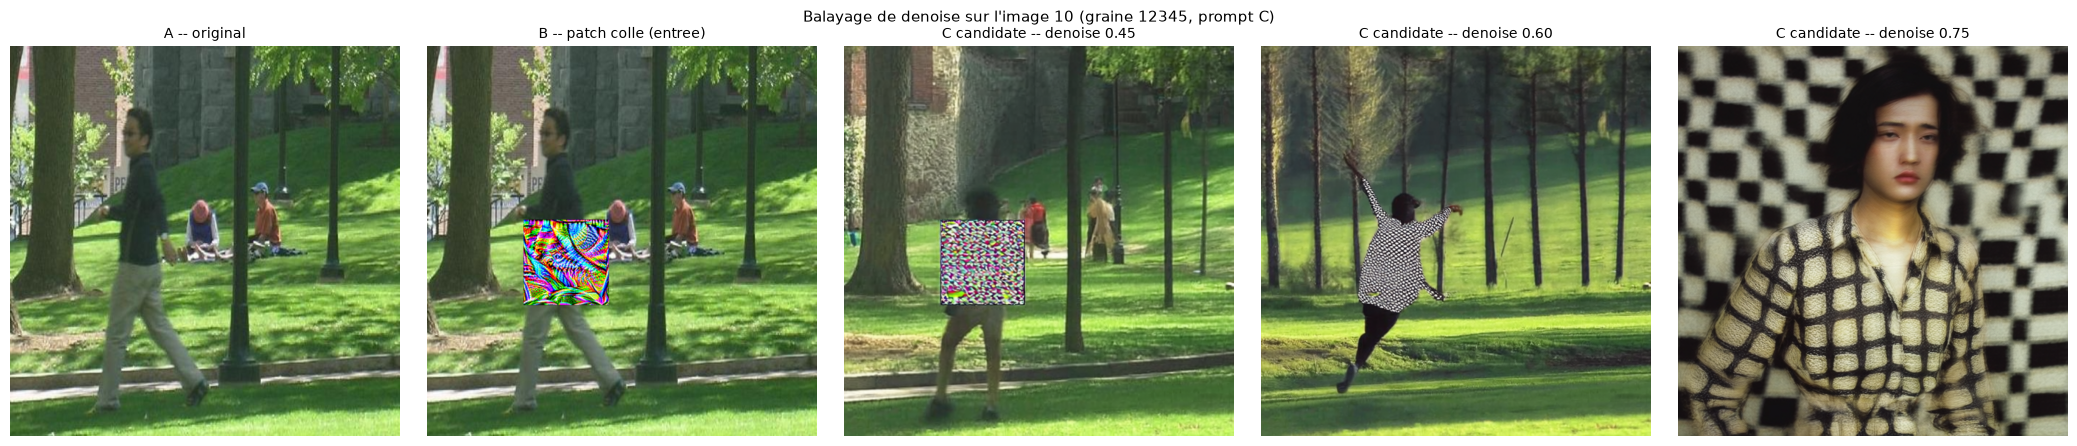

In [12]:
rs_sub = np.random.RandomState(7)
SUB_IDX = np.sort(rs_sub.choice(EV.shape[0], size=8, replace=False)).astype(int)
print("sous-ensemble C/D (cap declare, RandomState(7)) :", SUB_IDX.tolist(),
      "-- A et B restent mesures sur les %d images" % EV.shape[0])

PROMPT_C = ("Conserve la personne, sa pose, la scene et l'arriere-plan exactement comme sur l'image. "
            "Transforme uniquement le tissu de ses vetements : integre le motif geometrique noir et blanc "
            "present sur son torse comme texture meme du tissu du vetement, de facon realiste, en suivant "
            "les plis du tissu et les limites du vetement. Ne modifie rien d'autre.")

SWEEP_IMG = int(SUB_IDX[0])
DENOISE_SWEEP = [0.45, 0.60, 0.75]
sweep_out = {}
t0 = time.time()
for d in DENOISE_SWEEP:
    td = time.time()
    sweep_out[d] = run_i2i_with_retry(client, to_pil(EVp[SWEEP_IMG]), PROMPT_C, d, 12345,
                                      f"sweep_{int(d * 100):02d}.png")
    print("  denoise %.2f : %.0f s" % (d, time.time() - td))
print("balayage : %d appels en %.0f s" % (len(DENOISE_SWEEP), time.time() - t0))

fig, axes = plt.subplots(1, 5, figsize=(21, 4.5))
axes[0].imshow(to_pil(EV[SWEEP_IMG]));          axes[0].set_title("A -- original", fontsize=10)
axes[1].imshow(to_pil(EVp[SWEEP_IMG]));         axes[1].set_title("B -- patch colle (entree)", fontsize=10)
for j, d in enumerate(DENOISE_SWEEP):
    axes[2 + j].imshow(sweep_out[d])
    axes[2 + j].set_title("C candidate -- denoise %.2f" % d, fontsize=10)
for ax in axes:
    ax.axis("off")
plt.suptitle("Balayage de denoise sur l'image %d (graine 12345, prompt C)" % SWEEP_IMG, fontsize=11)
plt.tight_layout()
plt.show()

### Le choix retenu, et sa nature de jugé

La valeur retenue est `DENOISE_EVAL = 0.60`, ensuite **figée pour C comme pour D** — les deux conditions ne diffèrent que par l'image d'entrée (B contre A) et l'instruction de motif du prompt. Le critère est **pédagogique et déclaré**, pas métrique : le denoise le plus bas qui intègre le motif au tissu sans dénaturer la scène. Les trois rendus du balayage sont affichés ci-dessus précisément pour que ce jugement reste **vérifiable par le lecteur** — la fidélité du transfert est d'abord une question visuelle, et la section 14 y revient comme limite ; une métrique de remplacement (distance pixel entrée/sortie) est l'objet de l'exercice 3.

> **Note technique** : les durées affichées (198 s, 55 s, 51 s) mesurent la charge du service distant au moment de chaque appel — même image, même graine, seul le denoise varie — pas la difficulté du réglage.


## 12. Mesure — condition C : le vêtement stylé (la mesure centrale)

Pour chacune des 8 images du sous-ensemble : l'image **B** (patch collé) est uploadée, éditée par Qwen Image Edit 2509 avec le prompt C, `denoise` figé, graine 12 345. La sortie est reconvertie en tenseur et repasse par le même oracle que A et B — même seuil, même IoU, même `inbox_conf`. La galerie affiche pour chaque image l'entrée patchée et le vêtement stylé rendu.

  image 10 stylee en 51 s


  image 15 stylee en 54 s


  image 17 stylee en 53 s


  image 20 stylee en 46 s


  image 31 stylee en 45 s


  image 34 stylee en 43 s


  image 44 stylee en 47 s


  image 46 stylee en 43 s
condition C : 8 editions en 380 s (denoise 0.60, graine 12345)


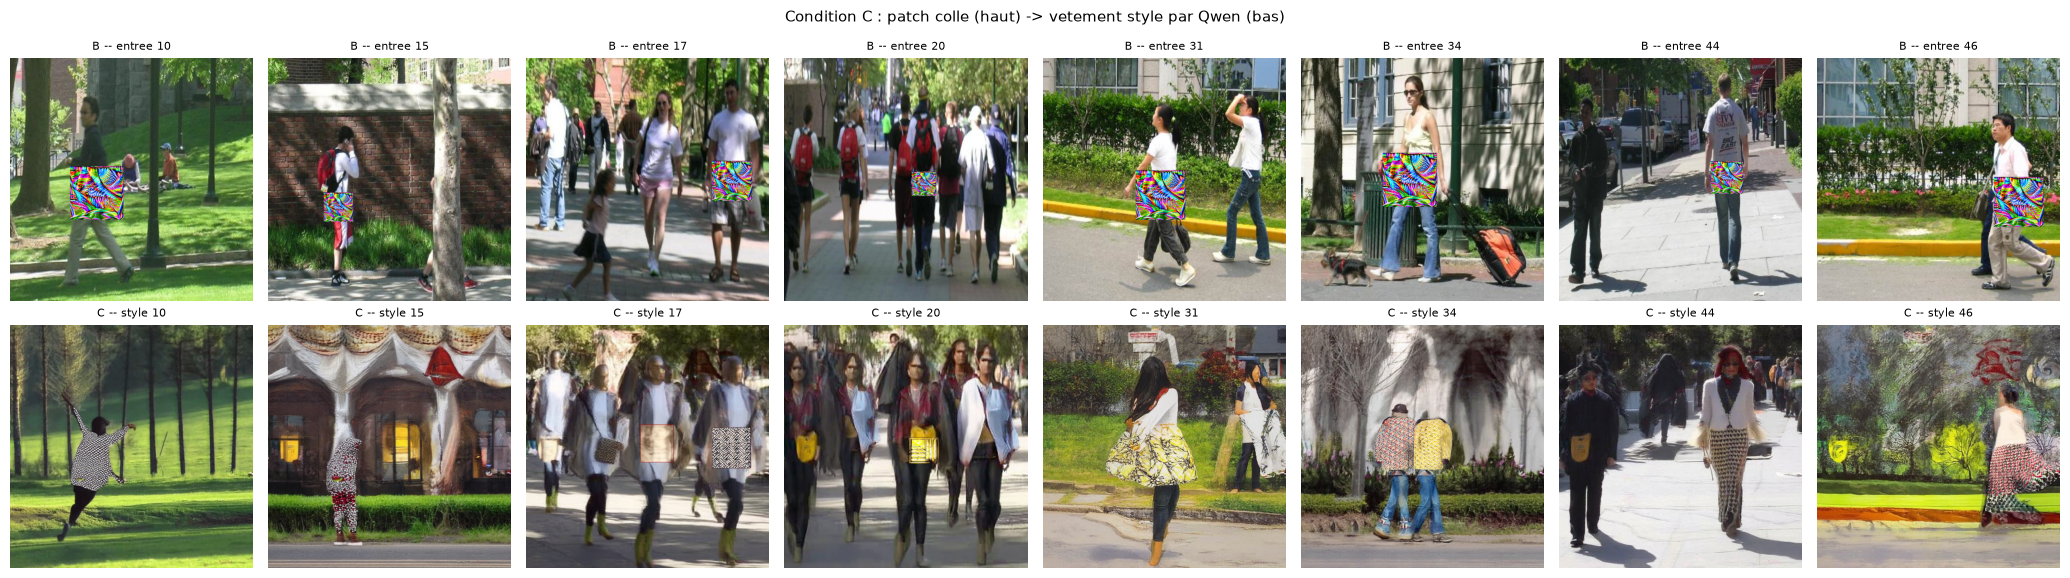

In [13]:
SEED_GEN = 12345
DENOISE_EVAL = 0.60   # choisi au balayage de la section 11

styled_C = {}
t0 = time.time()
for i in SUB_IDX:
    td = time.time()
    styled_C[int(i)] = run_i2i_with_retry(client, to_pil(EVp[int(i)]), PROMPT_C,
                                          DENOISE_EVAL, SEED_GEN, f"condC_{int(i):02d}.png")
    print("  image %2d stylee en %.0f s" % (i, time.time() - td))
print("condition C : %d editions en %.0f s (denoise %.2f, graine %d)"
      % (len(styled_C), time.time() - t0, DENOISE_EVAL, SEED_GEN))

fig, axes = plt.subplots(2, len(SUB_IDX), figsize=(2.6 * len(SUB_IDX), 6))
for j, i in enumerate(SUB_IDX):
    axes[0, j].imshow(to_pil(EVp[int(i)])); axes[0, j].set_title("B -- entree %d" % i, fontsize=8)
    axes[1, j].imshow(styled_C[int(i)]);    axes[1, j].set_title("C -- style %d" % i, fontsize=8)
for ax in axes.ravel():
    ax.axis("off")
plt.suptitle("Condition C : patch colle (haut) -> vetement style par Qwen (bas)", fontsize=11)
plt.tight_layout()
plt.show()

# conversion en tenseurs pour l'oracle
def pil_to_tensor(im):
    return torch.from_numpy(np.asarray(im.convert("RGB")).copy()).permute(2, 0, 1).float() / 255.0

EVc_list = [pil_to_tensor(styled_C[int(i)]) for i in SUB_IDX]
EVcB = torch.stack([EVB[int(i)] for i in SUB_IDX])
ALLc = [ALL_EV[int(i)] for i in SUB_IDX]
TGTc = [TGT_EV[int(i)] for i in SUB_IDX]

### Lecture visuelle avant la mesure

Deux choses à regarder dans la galerie avant tout chiffre : (1) **le motif a-t-il suivi** — le noir-blanc géométrique doit se retrouver dans le rendu du vêtement, déformé par les plis, et non plus un carré net par-dessus ; (2) **la scène a-t-elle tenu** — pose, arrière-plan et témoins doivent rester reconnaissables. L'évaluation qui suit ne « sait » rien de ces deux points : elle mesure seulement ce que voit YOLO. C'est la force du protocole — et sa limite, que la condition D viendra sonder.

In [14]:
# A et B restreints au meme sous-ensemble : la seule comparaison honnete avec C
EV_sub  = [EV[int(i)] for i in SUB_IDX]
EVp_sub = [EVp[int(i)] for i in SUB_IDX]
ALLs, TGTs = ALLc, TGTc
REC_As, OTH_As = eval_recall(m5, EV_sub, ALLs, TGTs)
REC_Bs, OTH_Bs = eval_recall(m5, EVp_sub, ALLs, TGTs)
CONF_As = inbox_conf(net5, torch.stack(EV_sub), EVcB)
CONF_Bs = inbox_conf(net5, torch.stack(EVp_sub), EVcB)

REC_C, OTH_C = eval_recall(m5, EVc_list, ALLc, TGTc)
CONF_C = inbox_conf(net5, torch.stack(EVc_list).to(DEV), EVcB)

print("CONDITION C -- vetement style (n = %d images, denoise %.2f, graine %d)"
      % (len(SUB_IDX), DENOISE_EVAL, SEED_GEN))
print("  sur le sous-ensemble :")
print("    recall CIBLE   : A %.3f | B %.3f | C %.3f" % (REC_As, REC_Bs, REC_C))
print("    recall TEMOINS : A %.3f | B %.3f | C %.3f" % (OTH_As, OTH_Bs, OTH_C))
print("    confiance in-box: A %.3f | B %.3f | C %.3f" % (CONF_As, CONF_Bs, CONF_C))
print("  cout total C vs A : recall %+.3f | confiance %+.3f" % (REC_C - REC_As, CONF_C - CONF_As))

CONDITION C -- vetement style (n = 8 images, denoise 0.60, graine 12345)
  sur le sous-ensemble :
    recall CIBLE   : A 1.000 | B 0.750 | C 1.000
    recall TEMOINS : A 1.000 | B 1.000 | C 0.250
    confiance in-box: A 0.786 | B 0.445 | C 0.648
  cout total C vs A : recall +0.000 | confiance -0.138


### Lecture de la condition C : le porteur n'a pas disparu

**Sortie obtenue** : sur le sous-ensemble (n = 8), recall cible C = **1,000** — identique à A — pour une confiance in-box à 0,648 (−0,138) ; ce sont les **témoins** qui s'effondrent (1,000 → 0,250).

Deux surprises par rapport au patch collé. (1) La cible — centre du prompt et du motif — reste détectée sur **toutes** les images, là où B la perdait déjà sur ce sous-ensemble (0,750). (2) L'effet le plus fort porte sur les piétons secondaires, que ni le patch ni le prompt ne visent. Ce profil — scène entière dégradée, cible épargnée — ressemble davantage au coût d'une **régénération de l'image** qu'à une attaque ciblée : c'est précisément ce que la condition D va mesurer, en régénérant les mêmes images **sans** motif ni instruction.


## 13. Mesure — condition D : le contrôle génératif

Même pipeline, même `denoise`, même graine — mais l'entrée est l'image **A** (non patchée) et le prompt est le prompt C **moins l'instruction de motif** : on demande le même re-render du vêtement, en texture réaliste, sans dire un mot du noir-blanc géométrique. D mesure ainsi le **coût propre du passage par le modèle génératif** — tout ce qui dégrade la détection en D dégraderait n'importe quel vêtement re-rendu, dazzle ou pas.

  image 10 re-rendue en 135 s


  image 15 re-rendue en 37 s


  image 17 re-rendue en 43 s


  image 20 re-rendue en 44 s


  image 31 re-rendue en 45 s


  image 34 re-rendue en 45 s


  image 44 re-rendue en 43 s


  image 46 re-rendue en 53 s
condition D : 8 editions en 444 s (denoise 0.60, graine 12345)


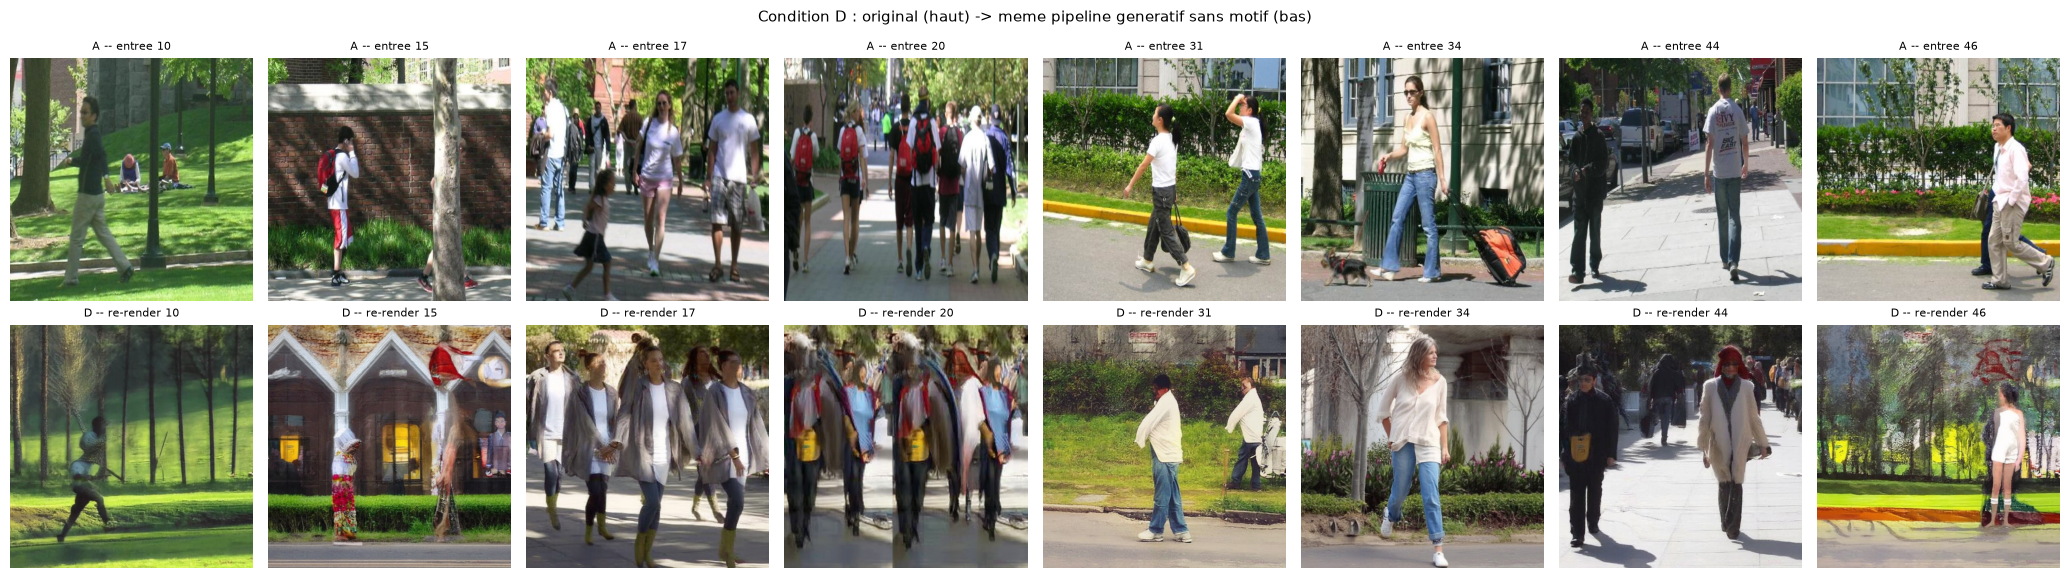

In [15]:
PROMPT_D = ("Conserve la personne, sa pose, la scene et l'arriere-plan exactement comme sur l'image. "
            "Transforme uniquement le tissu de ses vetements : donne au vetement une texture de tissu "
            "realiste et detailee, en suivant les plis du tissu et les limites du vetement. "
            "Ne modifie rien d'autre.")

styled_D = {}
t0 = time.time()
for i in SUB_IDX:
    td = time.time()
    styled_D[int(i)] = run_i2i_with_retry(client, to_pil(EV[int(i)]), PROMPT_D,
                                          DENOISE_EVAL, SEED_GEN, f"condD_{int(i):02d}.png")
    print("  image %2d re-rendue en %.0f s" % (i, time.time() - td))
print("condition D : %d editions en %.0f s (denoise %.2f, graine %d)"
      % (len(styled_D), time.time() - t0, DENOISE_EVAL, SEED_GEN))

fig, axes = plt.subplots(2, len(SUB_IDX), figsize=(2.6 * len(SUB_IDX), 6))
for j, i in enumerate(SUB_IDX):
    axes[0, j].imshow(to_pil(EV[int(i)].cpu())); axes[0, j].set_title("A -- entree %d" % i, fontsize=8)
    axes[1, j].imshow(styled_D[int(i)]);         axes[1, j].set_title("D -- re-render %d" % i, fontsize=8)
for ax in axes.ravel():
    ax.axis("off")
plt.suptitle("Condition D : original (haut) -> meme pipeline generatif sans motif (bas)", fontsize=11)
plt.tight_layout()
plt.show()

EVd_list = [pil_to_tensor(styled_D[int(i)]) for i in SUB_IDX]

### Le contrôle génératif à l'épreuve de l'oracle

Mêmes images d'entrée que A, même force d'édition et même graine que C : il ne reste plus, comme différence avec C, ni le motif collé ni son instruction — seulement l'habillage du vêtement. L'oracle va maintenant lire les quatre conditions du protocole.


In [16]:
REC_D, OTH_D = eval_recall(m5, EVd_list, ALLc, TGTc)
CONF_D = inbox_conf(net5, torch.stack(EVd_list).to(DEV), EVcB)

print("CONDITION D -- controle generatif (n = %d images, denoise %.2f, graine %d)"
      % (len(SUB_IDX), DENOISE_EVAL, SEED_GEN))
print("  recall CIBLE    : A %.3f | D %.3f  (cout du pipeline generatif seul : %+.3f)"
      % (REC_As, REC_D, REC_D - REC_As))
print("  recall TEMOINS  : A %.3f | D %.3f" % (OTH_As, OTH_D))
print("  confiance in-box: A %.3f | D %.3f  (%+.3f)" % (CONF_As, CONF_D, CONF_D - CONF_As))
print()
print("ATTRIBUTION (la reponse du notebook) :")
print("  chute totale du vetement dazzle  (C - A) : recall %+.3f | confiance %+.3f"
      % (REC_C - REC_As, CONF_C - CONF_As))
print("  cout du pipeline generatif       (D - A) : recall %+.3f | confiance %+.3f"
      % (REC_D - REC_As, CONF_D - CONF_As))
print("  part attribuable au MOTIF        (C - D) : recall %+.3f | confiance %+.3f"
      % (REC_C - REC_D, CONF_C - CONF_D))

CONDITION D -- controle generatif (n = 8 images, denoise 0.60, graine 12345)
  recall CIBLE    : A 1.000 | D 0.625  (cout du pipeline generatif seul : -0.375)
  recall TEMOINS  : A 1.000 | D 0.167
  confiance in-box: A 0.786 | D 0.589  (-0.197)

ATTRIBUTION (la reponse du notebook) :
  chute totale du vetement dazzle  (C - A) : recall +0.000 | confiance -0.138
  cout du pipeline generatif       (D - A) : recall -0.375 | confiance -0.197
  part attribuable au MOTIF        (C - D) : recall +0.375 | confiance +0.059


### Interprétation : trois écarts, un verdict renversé

La méthode est celle d'un essai contrôlé : D est le placebo de C. Deux issues étaient pré-enregistrées : si C ≈ D, le motif n'a rien apporté — toute chute constatée serait celle de *n'importe quel* vêtement re-rendu ; si C ≪ D, le motif aurait gardé de son pouvoir **à travers** la régénération.

| Écart | Mesuré (n = 8) | Ce qu'il dit |
|---|---|---|
| **C − A** | recall **+0,000** · conf −0,138 | le vêtement dazzle ne coûte **rien** au recall de la cible |
| **D − A** | recall **−0,375** · conf −0,197 | le pipeline génératif seul fait perdre 3 cibles sur 8 |
| **C − D** | recall **+0,375** · conf +0,059 | à re-render égal, l'instruction de motif va avec une cible *mieux* détectée |

**La mesure choisit une troisième voie, plus nette que les deux** : C ne chute pas sur la cible (8/8 détectés, conf 0,648) — l'attaque collée de B (0,750 / 0,445 sur ce même sous-ensemble) s'éteint entièrement une fois le motif passé au style. Et le seul coût mesurable en C (conf −0,138) est **inférieur** au coût du pipeline nu (−0,197) : l'instruction de motif va même, à re-render égal, avec une cible mieux détectée qu'en D. Le gradient adversarial du patch est une structure pixel fine, optimisée contre l'image *collée* ; le re-render la régénère comme il régénère tout le reste — témoins compris (0,250 en C, 0,167 en D).

La confiance in-box, annoncée comme discriminant plus fin que le recall, confirme la même lecture : C (0,648) reste au-dessus de D (0,589) et loin au-dessus du B collé (0,445). Aucun seuil opérationnel (0,40-0,50) ne sauverait une attaque que les chiffres ne montrent pas.


TABLEAU FINAL -- oracle yolov5nu gele, conf 0.25, IoU >= 0.50
cap declare : C et D limites a 8 cibles (np.random.RandomState(7)) ; denoise 0.60 ; graine 12345

condition                          n  recall cible recall temoins  conf in-box
A -- vetement non traite          59         1.000         0.952        0.783
B -- patch colle (ancre 4.2k)     59         0.661         0.952        0.412
A -- sous-ensemble C/D             8         1.000         1.000        0.786
B -- sous-ensemble C/D             8         0.750         1.000        0.445
C -- vetement style                8         1.000         0.250        0.648
D -- controle generatif            8         0.625         0.167        0.589

C vs A : recall +0.000 | conf -0.138   (cout total)
D vs A : recall -0.375 | conf -0.197   (pipeline generatif seul)
C vs D : recall +0.375 | conf +0.059   (part du MOTIF dazzle)

appels generatifs distants : 19 (balayage inclus) | retries inclus dans le compteur d'essais


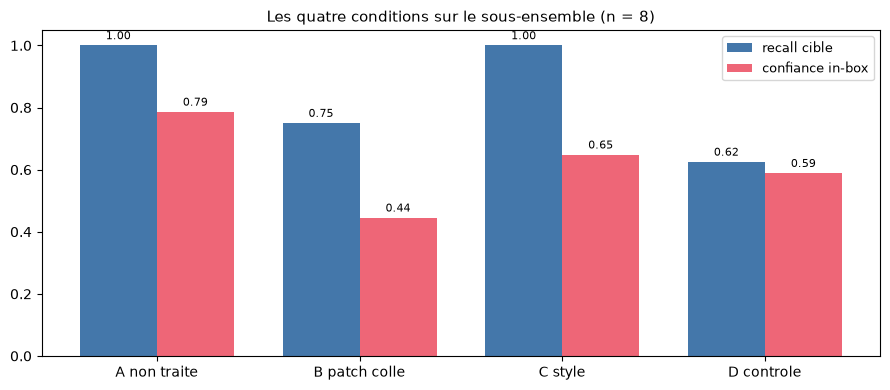

In [17]:
lignes = [
    ("A -- vetement non traite", EV.shape[0], REC_A, OTH_A, CONF_A),
    ("B -- patch colle (ancre 4.2k)", EV.shape[0], REC_B, OTH_B, CONF_B),
    ("A -- sous-ensemble C/D", len(SUB_IDX), REC_As, OTH_As, CONF_As),
    ("B -- sous-ensemble C/D", len(SUB_IDX), REC_Bs, OTH_Bs, CONF_Bs),
    ("C -- vetement style", len(SUB_IDX), REC_C, OTH_C, CONF_C),
    ("D -- controle generatif", len(SUB_IDX), REC_D, OTH_D, CONF_D),
]
print("TABLEAU FINAL -- oracle yolov5nu gele, conf 0.25, IoU >= 0.50")
print("cap declare : C et D limites a 8 cibles (np.random.RandomState(7)) ; denoise %.2f ; graine %d"
      % (DENOISE_EVAL, SEED_GEN))
print()
print("%-30s %5s %13s %13s %12s" % ("condition", "n", "recall cible", "recall temoins", "conf in-box"))
for nom, n, r, o, c in lignes:
    print("%-30s %5d %13.3f %13.3f %12.3f" % (nom, n, r, o, c))
print()
print("C vs A : recall %+.3f | conf %+.3f   (cout total)" % (REC_C - REC_As, CONF_C - CONF_As))
print("D vs A : recall %+.3f | conf %+.3f   (pipeline generatif seul)" % (REC_D - REC_As, CONF_D - CONF_As))
print("C vs D : recall %+.3f | conf %+.3f   (part du MOTIF dazzle)" % (REC_C - REC_D, CONF_C - CONF_D))
print()
print("appels generatifs distants : %d (balayage inclus) | retries inclus dans le compteur d'essais"
      % N_APPELS_DISTANTS[0])

fig, ax = plt.subplots(figsize=(9, 4))
conds = ["A", "B", "C", "D"]
recalls = [REC_As, REC_Bs, REC_C, REC_D]
confs = [CONF_As, CONF_Bs, CONF_C, CONF_D]
x = np.arange(len(conds)); w = 0.38
ax.bar(x - w / 2, recalls, w, label="recall cible", color="#4477aa")
ax.bar(x + w / 2, confs, w, label="confiance in-box", color="#ee6677")
ax.set_xticks(x); ax.set_xticklabels(["A non traite", "B patch colle", "C style", "D controle"])
ax.set_ylim(0, 1.05); ax.legend(fontsize=9)
ax.set_title("Les quatre conditions sur le sous-ensemble (n = %d)" % len(SUB_IDX), fontsize=11)
for xi, (r, c) in enumerate(zip(recalls, confs)):
    ax.text(xi - w / 2, r + 0.02, "%.2f" % r, ha="center", fontsize=8)
    ax.text(xi + w / 2, c + 0.02, "%.2f" % c, ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## 14. Limites nommées

Ce que ce protocole **ne prouve pas** — à lire avant de citer les chiffres :

1. **Le style génératif n'est pas le monde physique.** Qwen re-rend une image ; il ne simule ni la distance, ni l'éclairage du jour, ni le mouvement, ni le pliage réel d'un tissu imprimé. C'est un proxy intermédiaire entre le collage numérique (4.2k) et l'attaque physique — plus sévère que le premier, moins que la seconde.
2. **Huit images.** Le cap sur C/D est un cap de coût (30-60 s l'appel) : les comparaisons C/D/A/B du sous-ensemble portent sur n = 8 — les différences de l'ordre du dixième de recall y sont une image près. En particulier, l'écart C − D qui fonde le verdict (+0,375) vaut **trois images** de différence : le verdict « l'attaque ne survit pas » repose sur l'absence totale de chute en C (8/8 détectés, cohérente avec la confiance), pas sur la magnitude exacte de C − D. Les ancres A/B pleines (n = 59) restent solides.
3. **Une graine générative, un prompt, un denoise.** La variance d'une édition à l'autre (graine, formulation) n'est pas balayée ici ; la graine 12 345 est fixée pour la reproductibilité, pas pour représenter le modèle en moyenne.
4. **Un seul oracle.** 4.2k a montré que l'attaque est spécifique au détecteur visé ; les présentes mesures ne disent rien du transfert vers d'autres détecteurs (yolo11n le montrait quasi nul pour le patch collé).
5. **La fidélité du transfert n'est pas quantifiée** dans la boucle principale — l'exercice 3 l'attaque par la distance pixel, mais « le motif est-il le même » reste d'abord un jugé visuel, que les galeries embarquées permettent au lecteur de faire.


## 15. Exercice 1 — Le seuil de confiance déplace-t-il le problème ?

4.2k a montré sur le patch collé qu'un seuil plus haut rejette le porteur… avec les détections légitimes. Reprenez la question ici, sur les quatre conditions : pour chaque seuil de `0.25` à `0.50` (pas 0.05 environ), recalculez le recall cible de A, B, C, D sur le sous-ensemble (`eval_recall(..., conf=conf)`), puis tracez les quatre courbes. Question directrice : existe-t-il un seuil où le porteur du vêtement stylé redevient systématiquement invisible **sans** sacrifier les témoins ?

In [18]:
# Exercice 1 a completer : balayage du seuil de confiance sur les 4 conditions (sous-ensemble)
# Etape 1 : seuils = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
# Etape 2 : pour chaque seuil, eval_recall(m5, images_condition, ALLc, TGTc, conf=seuil) -- images :
#           A -> EV_sub, B -> EVp_sub, C -> EVc_list, D -> EVd_list
# Etape 3 : plt.plot(seuil, recall) x4 avec legende + lecture du point ou C s'effondre vs les temoins
result_ex1 = None  # TODO etudiant : {"A": {seuil: recall_cible}, ...}
print("Exercice 1 a completer : balayage du seuil de confiance (4 conditions, sous-ensemble)")

Exercice 1 a completer : balayage du seuil de confiance (4 conditions, sous-ensemble)


## 16. Exercice 2 — Le patch collé annonce-t-il le vêtement stylé ?

Par image du sous-ensemble : la confiance in-box en B (patch collé) prévoit-elle la confiance in-box en C (vêtement stylé) ? Calculez les deux confiances par image (une boucle sur `raw_out` comme dans `inbox_conf`, sans moyenner), puis la corrélation de rang de Spearman (scipy) et le nuage de points. Question directrice : le transfert de style préserve-t-il la *hiérarchie* des cibles — les porteurs les mieux camouflés par le patch restent-ils les mieux camouflés une fois le motif intégré au tissu ?

In [19]:
# Exercice 2 a completer : correlation par image entre la confiance B (patch) et la confiance C (style)
# Etape 1 : pour chaque i du sous-ensemble, confiance max dans EVcB[k] pour EVp_sub[k] puis EVc_list[k]
#           (meme logique qu'inbox_conf, mais image par image -- refactorez inbox_conf en fonction par image)
# Etape 2 : spearmanr(confs_B, confs_C) -- from scipy.stats import spearmanr
# Etape 3 : nuage de points conf_B x conf_C + droite identitaire + interpretation du rho
result_ex2 = None  # TODO etudiant : (rho_spearman, p_value, nuage_de_points)
print("Exercice 2 a completer : correlation par image patch colle <-> vetement style")

Exercice 2 a completer : correlation par image patch colle <-> vetement style


## 17. Exercice 3 — Fidélité du transfert contre coût de détection

Le prompt C demande d'*intégrer* le motif — avec quel succès selon les images ? Pour chaque image du sous-ensemble, calculez la distance L2 moyenne par pixel entre l'entrée B (`EVp_sub[k]`) et la sortie C (`EVc_list[k]`), puis confrontez-la à la chute de confiance in-box (C − A par image). Nuage de points et question directrice : le motif est-il **mieux intégré** (distance plus faible) précisément quand il **protège mieux** (confiance plus effondrée) — ou l'inverse ? Une corrélation positive suggérerait que le modèle « habille » d'autant mieux le motif qu'il l'a bien compris, ce qui est une tout autre histoire qu'un simple collage.

In [20]:
# Exercice 3 a completer : distance L2 (patch -> style) contre chute de confiance in-box, par image
# Etape 1 : l2_k = float(((EVp_sub[k].cpu() - EVc_list[k]) ** 2).mean().sqrt()) pour chaque k du sous-ensemble
# Etape 2 : chute_k = conf_inbox_C_k - conf_inbox_A_k (confiances par image, cf. exercice 2)
# Etape 3 : nuage de points (l2, chute) + coefficient de correlation + interpretation
result_ex3 = None  # TODO etudiant : liste de couples (distance_l2, chute_confiance)
print("Exercice 3 a completer : fidelite du transfert vs cout de detection")

Exercice 3 a completer : fidelite du transfert vs cout de detection


## Conclusion

Ce notebook a déplacé le patch dazzle de 4.2k d'un **carré collé sur l'image** vers un **motif intégré au tissu d'un vêtement re-rendu** par un modèle d'édition SOTA — et il a mesuré ce que ce voyage coûte à l'attaque, avec le contrôle génératif qui sépare le prix du motif du prix du médium.

**Ce qu'il faut retenir :**

1. **Un protocole d'attribution à quatre conditions** : A (référence), B (ancre répliquée de 4.2k — mesurée ici à 0,661 / 0,412, classe de l'ancre 0,559 / 0,343), C (la mesure centrale), D (le placebo génératif). Sans D, aucune lecture de C n'aurait été interprétable.
2. **La mesure, pas l'image, est le livrable — et elle renverse la lecture attendue** : le patch collé efface un porteur sur trois (B 0,661) ; le même motif intégré au tissu n'efface **personne** (C 1,000, conf 0,648 contre 0,786 en A). Le contrôle D attribue toute la dégradation mesurable au pipeline génératif lui-même (recall −0,375, témoins effondrés à 0,167) : en l'état, le style-transfer n'est pas un vecteur de cette attaque — il filtre le signal adversarial tout en dégradant la scène pour son propre compte.
3. **L'écart digital-physique reste entier, et s'élargit d'un cran** : entre le collage numérique (4.2k) et le monde physique s'interpose désormais un filtre génératif destructeur du signal — avant même la question des plis, de la distance et de l'éclairage. Les limites nommées (n = 8, une graine, un denoise, un oracle) disent exactement jusqu'où vont ces chiffres.

La lignée détection s'arrête ici pour l'instant côté attaque : la défense (fine-tuning adversarial) est restée l'exercice 3 de 4.2k — elle attend son propre notebook.

## Références

- Thys, Van Ranst, Goedemé — *Fooling automated surveillance cameras: adversarial patches to person-detection* (CVPR Workshops 2019) — la méthode du patch paramétrable.
- Harvey, Adam — *CV Dazzle: camouflage from computer vision* (2010-2013) — le dazzle porté, maquillage et coiffure, dont ce notebook est l'écho génératif.
